In [44]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader, TensorDataset

# 设置随机种子
torch.manual_seed(42)
np.random.seed(42)

In [45]:
def scaled_dot_product_attention(Q, K, V, mask=None, verbose=False):
    """
    缩放点积注意力

    Q: (B, Tq, d_k), K: (B, Tk, d_k), V: (B, Tk, d_v)
    mask: (B, Tq, Tk)，masked位置为0
    返回: out (B, Tq, d_v), attn (B, Tq, Tk)
    """
    d_k = Q.shape[-1]
    scores = torch.matmul(Q, K.transpose(-2, -1)) / (d_k ** 0.5)

    if mask is not None:
        scores = scores.masked_fill(mask == 0, -1e9)

    attn = F.softmax(scores, dim=-1)
    out = torch.matmul(attn, V)

    if verbose:
        print(f"out shape: {out.shape}, attn.sum(dim=-1): {attn.sum(dim=-1)}")

    return out, attn

In [46]:
# 测试无mask
print("=== 测试1: 无mask ===")
Q = torch.randn(2, 3, 8)
K = torch.randn(2, 4, 8)
V = torch.randn(2, 4, 16)
out, attn = scaled_dot_product_attention(Q, K, V, verbose=True)
print(f"attn:\n{attn}\n")     # 4个位置都有权重

# 测试有mask: 屏蔽后两个位置
print("=== 测试2: 有mask (屏蔽位置2,3) ===")
mask = torch.ones(2, 3, 4)
mask[:, :, 2:] = 0
out, attn = scaled_dot_product_attention(Q, K, V, mask, verbose=True)
print(f"attn (位置2,3权重应为0):\n{attn}")   # 位置2,3权重≈0

=== 测试1: 无mask ===
out shape: torch.Size([2, 3, 16]), attn.sum(dim=-1): tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000]])
attn:
tensor([[[0.0375, 0.0082, 0.5885, 0.3658],
         [0.1230, 0.3095, 0.2305, 0.3370],
         [0.1291, 0.3594, 0.4657, 0.0459]],

        [[0.1204, 0.3876, 0.1020, 0.3901],
         [0.1446, 0.1829, 0.5394, 0.1330],
         [0.1446, 0.0557, 0.3943, 0.4054]]])

=== 测试2: 有mask (屏蔽位置2,3) ===
out shape: torch.Size([2, 3, 16]), attn.sum(dim=-1): tensor([[1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000]])
attn (位置2,3权重应为0):
tensor([[[0.8196, 0.1804, 0.0000, 0.0000],
         [0.2844, 0.7156, 0.0000, 0.0000],
         [0.2643, 0.7357, 0.0000, 0.0000]],

        [[0.2370, 0.7630, 0.0000, 0.0000],
         [0.4415, 0.5585, 0.0000, 0.0000],
         [0.7219, 0.2781, 0.0000, 0.0000]]])


In [47]:
class AttentionLayer(nn.Module):
    """单头自注意力层"""
    def __init__(self, d_model, d_k, d_v):
        super().__init__()
        self.W_q = nn.Linear(d_model, d_k, bias=False)
        self.W_k = nn.Linear(d_model, d_k, bias=False)
        self.W_v = nn.Linear(d_model, d_v, bias=False)

    def forward(self, X, mask=None):
        Q = self.W_q(X)
        K = self.W_k(X)
        V = self.W_v(X)
        H, attn = scaled_dot_product_attention(Q, K, V, mask, verbose=True)
        return H, attn

# 测试
X = torch.randn(2, 5, 32)
attn_layer = AttentionLayer(32, 16, 16)
H, attn = attn_layer(X)
print(f"\n输入X: {X.shape}, 输出H: {H.shape}, attn: {attn.shape}")

out shape: torch.Size([2, 5, 16]), attn.sum(dim=-1): tensor([[1.0000, 1.0000, 1.0000, 1.0000, 1.0000],
        [1.0000, 1.0000, 1.0000, 1.0000, 1.0000]], grad_fn=<SumBackward1>)

输入X: torch.Size([2, 5, 32]), 输出H: torch.Size([2, 5, 16]), attn: torch.Size([2, 5, 5])


In [48]:
class PointerRetrievalModel(nn.Module):
    """
    指针检索模型
    Q 编码位置（我要找位置p），K 编码内容+位置（我是token x[i]，在位置i），
    两者在同一个语义空间，Q·K^T 才能正确匹配。
    """
    def __init__(self, vocab_size, seq_len, d_model, d_k, d_v):
        super().__init__()
        self.seq_len = seq_len
        self.d_model = d_model
        self.d_k = d_k

        self.token_embedding = nn.Embedding(vocab_size, d_model)
        self.position_embedding = nn.Embedding(seq_len, d_model)
        self.W_k = nn.Linear(d_model, d_k, bias=False)
        self.W_v = nn.Linear(d_model, d_v, bias=False)
        self.query_embedding = nn.Embedding(seq_len, d_k)
        self.output_layer = nn.Linear(d_v, vocab_size)

    def forward(self, x, p):
        B, L = x.shape

        positions = torch.arange(L, device=x.device).unsqueeze(0).expand(B, -1)
        X = self.token_embedding(x) + self.position_embedding(positions)

        K = self.W_k(X)  # (B, L, d_k)
        V = self.W_v(X)  # (B, L, d_v)
        Q = self.query_embedding(p).unsqueeze(1)  # (B, 1, d_k)

        scores = torch.matmul(Q, K.transpose(-2, -1)) / (self.d_k ** 0.5)
        attn = F.softmax(scores, dim=-1)
        H = torch.matmul(attn, V)

        H = H.squeeze(1)
        attn = attn.squeeze(1)
        logits = self.output_layer(H)

        return logits, attn

    def count_parameters(self):
        return sum(p.numel() for p in self.parameters())

In [49]:
def generate_data(vocab_size, seq_len, num_samples):
    """生成指针检索数据: x随机token序列, p随机位置, y=x[p]"""
    x = torch.randint(0, vocab_size, (num_samples, seq_len))
    p = torch.randint(0, seq_len, (num_samples,))
    y = x[torch.arange(num_samples), p]
    return x, p, y

# 测试
vocab_size, seq_len = 20, 16
x, p, y = generate_data(vocab_size, seq_len, 5)
print(f"x: {x.tolist()}\np: {p.tolist()}\ny=x[p]: {y.tolist()}")

x: [[5, 13, 13, 14, 14, 16, 12, 17, 15, 7, 14, 10, 14, 9, 15, 16], [17, 16, 16, 5, 0, 19, 8, 19, 7, 15, 18, 8, 13, 1, 0, 18], [14, 15, 4, 16, 1, 8, 10, 0, 13, 15, 17, 1, 7, 17, 1, 12], [8, 15, 16, 0, 13, 14, 4, 18, 4, 8, 11, 15, 11, 18, 17, 0], [0, 0, 2, 19, 9, 14, 15, 14, 13, 7, 6, 13, 16, 13, 16, 18]]
p: [3, 3, 10, 7, 3]
y=x[p]: [14, 5, 17, 18, 19]


In [50]:
def train_model(model, train_loader, test_loader, epochs, lr=1e-3, device='cpu'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    train_losses, test_accs, test_epochs = [], [], []

    for epoch in range(epochs):
        model.train()
        total_loss = 0
        for x, p, y in train_loader:
            x, p, y = x.to(device), p.to(device), y.to(device)
            optimizer.zero_grad()
            logits, _ = model(x, p)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        train_losses.append(total_loss / len(train_loader))

        if (epoch + 1) % 10 == 0:
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for x, p, y in test_loader:
                    x, p, y = x.to(device), p.to(device), y.to(device)
                    logits, _ = model(x, p)
                    correct += (logits.argmax(dim=-1) == y).sum().item()
                    total += y.size(0)
            acc = correct / total
            test_accs.append(acc)
            test_epochs.append(epoch + 1)
            print(f"Epoch {epoch+1:3d}/{epochs}, Loss: {train_losses[-1]:.4f}, Test Acc: {acc:.4f}")

    print("训练完成!")
    return train_losses, test_accs, test_epochs

In [51]:
def visualize_attention(model, x, p, y, device='cpu'):
    """
    可视化注意力权重

    参数:
        model: 训练好的模型
        x: 输入序列 (L,)
        p: 指针位置
        y: 目标值
        device: 设备
    """
    model.eval()

    with torch.no_grad():
        x_tensor = x.unsqueeze(0).to(device)
        p_tensor = torch.tensor([p]).to(device)
        logits, attn = model(x_tensor, p_tensor)
        pred = logits.argmax(dim=-1).item()
        attn_weights = attn.squeeze().cpu().numpy()

    # 打印详细信息
    print("\n" + "=" * 60)
    print("注意力可视化")
    print("=" * 60)
    print(f"输入序列: {x.tolist()}")
    print(f"指针位置 p = {p}")
    print(f"目标值 y = {y}")
    print(f"模型预测 = {pred}")
    print(f"预测正确: {'✓' if pred == y else '✗'}")

    print(f"\n注意力权重 (序列长度 {len(attn_weights)}):")
    print("-" * 50)
    for i, w in enumerate(attn_weights):
        marker = " ← 指针位置" if i == p else ""
        bar = "█" * int(w * 50)
        print(f"位置 {i:2d}: {w:.4f} {bar:50s}{marker}")

    print(f"\n注意力权重总和: {attn_weights.sum():.4f}")
    print(f"argmax(注意力) = {attn_weights.argmax()}, 期望指针位置 = {p}")

    # 绘制柱状图
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # 柱状图
    colors = ['red' if i == p else 'steelblue' for i in range(len(attn_weights))]
    bars = ax1.bar(range(len(attn_weights)), attn_weights, color=colors, alpha=0.7)
    ax1.axvline(x=p, color='red', linestyle='--', alpha=0.5, linewidth=2, label=f'Pointer (p={p})')
    ax1.set_xlabel('Sequence Position', fontsize=12)
    ax1.set_ylabel('Attention Weight', fontsize=12)
    ax1.set_title(f'Attention Weights Distribution\nTarget: {y}, Prediction: {pred}', fontsize=12)
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    # 热力图
    attn_map = attn_weights.reshape(1, -1)
    im = ax2.imshow(attn_map, aspect='auto', cmap='YlOrRd', vmin=0, vmax=1)
    ax2.set_xlabel('Sequence Position', fontsize=12)
    ax2.set_ylabel('Query (Pointer)', fontsize=12)
    ax2.set_title('Attention Heatmap', fontsize=12)
    ax2.set_xticks(range(len(attn_weights)))
    ax2.set_yticks([0])
    ax2.set_yticklabels([f'p={p}'])

    # 添加颜色条
    plt.colorbar(im, ax=ax2, label='Attention Weight')

    plt.tight_layout()
    plt.show()

    return attn_weights

def plot_training_curves(train_losses, test_accs, test_epochs):
    """绘制训练曲线"""
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

    # 损失曲线
    ax1.plot(train_losses, 'b-', alpha=0.7)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.set_title('Training Loss', fontsize=12)
    ax1.grid(True, alpha=0.3)

    # 准确率曲线
    ax2.plot(test_epochs, test_accs, 'r-o', alpha=0.7)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy', fontsize=12)
    ax2.set_title('Test Accuracy', fontsize=12)
    ax2.set_ylim(0, 1)
    ax2.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

In [52]:
# 超参数设置
vocab_size = 20    # token 0-19
seq_len = 16       # 序列长度
d_model = 32       # 嵌入维度
d_k = 16          # Key/Query维度
d_v = 16          # Value维度
batch_size = 32
epochs = 50        # 修复后收敛更快，50轮足够达到~100%

# 设备配置
device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f"使用设备: {device}")
print(f"\n超参数:")
print(f"  词表大小: {vocab_size}")
print(f"  序列长度: {seq_len}")
print(f"  嵌入维度: {d_model}")
print(f"  K/Q维度: {d_k}")
print(f"  V维度: {d_v}")
print(f"  批次大小: {batch_size}")
print(f"  训练轮数: {epochs}")

使用设备: cpu

超参数:
  词表大小: 20
  序列长度: 16
  嵌入维度: 32
  K/Q维度: 16
  V维度: 16
  批次大小: 32
  训练轮数: 50


In [53]:
# 生成训练和测试数据
train_size = 5000
test_size = 1000

print("生成数据...")
train_x, train_p, train_y = generate_data(vocab_size, seq_len, train_size)
test_x, test_p, test_y = generate_data(vocab_size, seq_len, test_size)

# 创建DataLoader
train_dataset = TensorDataset(train_x, train_p, train_y)
test_dataset = TensorDataset(test_x, test_p, test_y)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print(f"训练集大小: {train_size}")
print(f"测试集大小: {test_size}")
print(f"训练批次数: {len(train_loader)}")
print(f"测试批次数: {len(test_loader)}")

# 展示一个batch的数据
sample_batch = next(iter(train_loader))
print(f"\n一个batch的数据形状:")
print(f"  x: {sample_batch[0].shape}")
print(f"  p: {sample_batch[1].shape}")
print(f"  y: {sample_batch[2].shape}")

生成数据...
训练集大小: 5000
测试集大小: 1000
训练批次数: 157
测试批次数: 32

一个batch的数据形状:
  x: torch.Size([32, 16])
  p: torch.Size([32])
  y: torch.Size([32])


In [54]:
# 创建模型
model = PointerRetrievalModel(vocab_size, seq_len, d_model, d_k, d_v)

print("模型结构:")
print("=" * 60)
print(model)
print("=" * 60)
print(f"\n模型参数量: {model.count_parameters():,}")

# 测试前向传播
print("\n测试前向传播...")
test_x, test_p, _ = next(iter(train_loader))
test_x = test_x[:2]
test_p = test_p[:2]

logits, attn = model(test_x, test_p)
print(f"输入x形状: {test_x.shape}")
print(f"输入p形状: {test_p.shape}")
print(f"输出logits形状: {logits.shape}")
print(f"输出注意力形状: {attn.shape}")

模型结构:
PointerRetrievalModel(
  (token_embedding): Embedding(20, 32)
  (position_embedding): Embedding(16, 32)
  (W_k): Linear(in_features=32, out_features=16, bias=False)
  (W_v): Linear(in_features=32, out_features=16, bias=False)
  (query_embedding): Embedding(16, 16)
  (output_layer): Linear(in_features=16, out_features=20, bias=True)
)

模型参数量: 2,772

测试前向传播...
输入x形状: torch.Size([2, 16])
输入p形状: torch.Size([2])
输出logits形状: torch.Size([2, 20])
输出注意力形状: torch.Size([2, 16])


Epoch  10/50, Loss: 0.0025, Test Acc: 1.0000
Epoch  20/50, Loss: 0.0004, Test Acc: 1.0000
Epoch  30/50, Loss: 0.0001, Test Acc: 1.0000
Epoch  40/50, Loss: 0.0000, Test Acc: 1.0000
Epoch  50/50, Loss: 0.0000, Test Acc: 1.0000
训练完成!


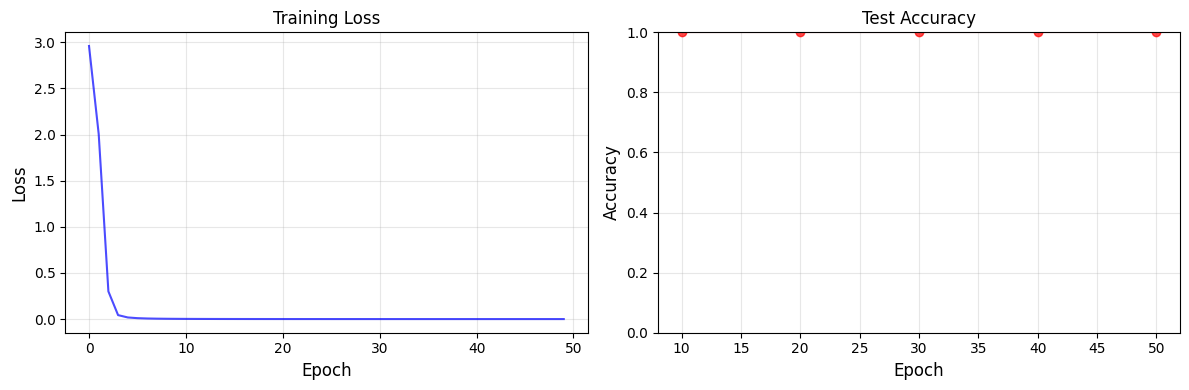

In [55]:
# 训练模型
train_losses, test_accs, test_epochs = train_model(
    model, train_loader, test_loader,
    epochs=epochs, lr=1e-3, device=device
)

# 绘制训练曲线
plot_training_curves(train_losses, test_accs, test_epochs)

随机选择样本 #0

注意力可视化
输入序列: [11, 12, 16, 13, 7, 10, 15, 0, 15, 8, 12, 15, 14, 16, 15, 16]
指针位置 p = 6
目标值 y = 9
模型预测 = 15
预测正确: ✗

注意力权重 (序列长度 16):
--------------------------------------------------
位置  0: 0.0000                                                   
位置  1: 0.0001                                                   
位置  2: 0.0011                                                   
位置  3: 0.0041                                                   
位置  4: 0.0002                                                   
位置  5: 0.0012                                                   
位置  6: 0.9834 █████████████████████████████████████████████████  ← 指针位置
位置  7: 0.0005                                                   
位置  8: 0.0002                                                   
位置  9: 0.0056                                                   
位置 10: 0.0002                                                   
位置 11: 0.0001                                                   
位置 12: 0.0000      

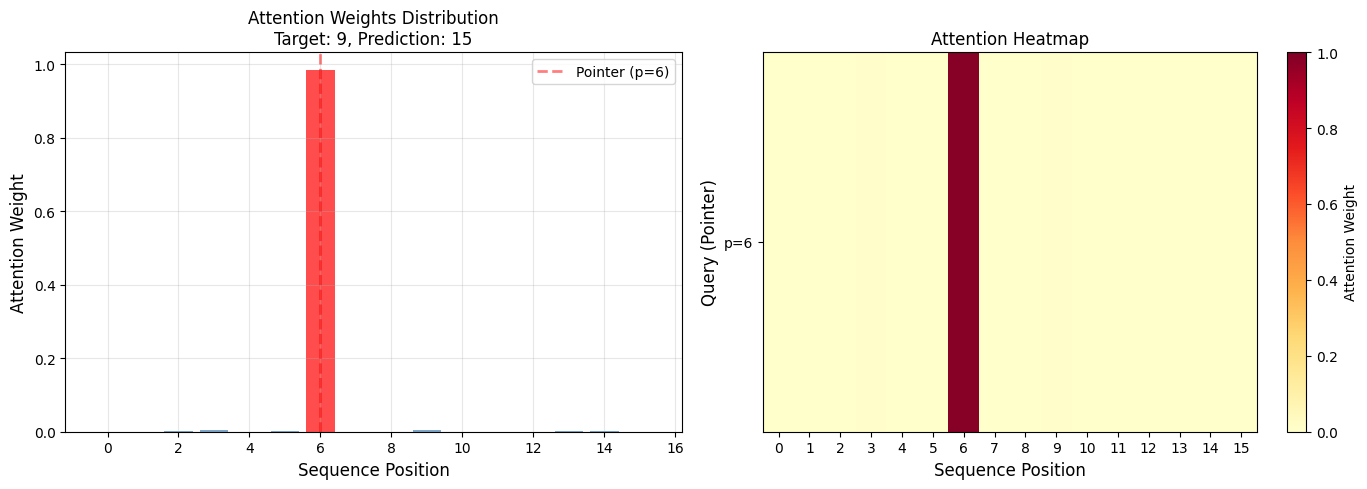

In [56]:
# 随机选择一个测试样本进行可视化
idx = np.random.randint(0, len(test_x))
x_sample = test_x[idx]
p_sample = test_p[idx].item()
y_sample = test_y[idx].item()

print(f"随机选择样本 #{idx}")
attn_weights = visualize_attention(model, x_sample, p_sample, y_sample, device)

In [57]:
# 最终评估
model.eval()
correct, total = 0, 0

with torch.no_grad():
    for x, p, y in test_loader:
        x, p, y = x.to(device), p.to(device), y.to(device)
        logits, attn = model(x, p)
        pred = logits.argmax(dim=-1)
        correct += (pred == y).sum().item()
        total += y.size(0)

final_acc = correct / total
print(f"测试集准确率: {final_acc:.4f} ({correct}/{total})")

测试集准确率: 1.0000 (1000/1000)
